In [ ]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score

df=pd.read_csv(r"C:\Users\Vaish\Desktop\ML LAB DATASETS LOGISTIC REGRESSION\BATCH-6\29_athlete_injury.csv")


In [12]:
print("------------HEAD---------------")
print(df.head())
print("-----------TAIL-----------------")
print(df.tail())
print("--------------DESCRIBE-----------")
print(df.describe())
print("----------------INFO-------------")
print(df.info())
print("--------------------MISSING VALUES----------------")
print(df.isnull().sum())


------------HEAD---------------
   training_hours_week  age_years  previous_injuries  fatigue_score  \
0                12.83      25.63                  6           7.51   
1                11.33      26.77                  0           4.87   
2                 3.37      16.66                  8           5.31   
3                24.74      23.45                  7           4.04   
4                15.42      26.29                  2           8.78   

     position  league_level training_type  got_injured  
0  Midfielder  Professional    Individual            0  
1     Forward  Professional    Individual            0  
2    Defender       Amateur          Team            1  
3  Goalkeeper       Amateur    Individual            0  
4    Defender       Amateur          Team            0  
-----------TAIL-----------------
     training_hours_week  age_years  previous_injuries  fatigue_score  \
295                11.14      36.13                  8           3.00   
296                 

In [13]:
X = df.drop("got_injured", axis=1)
y = df["got_injured"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 10)
Testing data: (60, 10)


In [14]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [15]:
z = model.decision_function(X_test)

probability = 1 / (1 + np.exp(-z))

print("Sigmoid probabilities:")
print(probability[:10])

Sigmoid probabilities:
[0.53665358 0.79647374 0.13763345 0.50914104 0.39371791 0.32594695
 0.86490299 0.59689141 0.26521794 0.13659321]


In [16]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("Predicted labels:")
print(y_pred[:10])

print("\nPredicted probabilities:")
print(y_prob[:10])

Predicted labels:
[1 1 0 1 0 0 1 1 0 0]

Predicted probabilities:
[0.53665358 0.79647374 0.13763345 0.50914104 0.39371791 0.32594695
 0.86490299 0.59689141 0.26521794 0.13659321]


In [17]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Confusion Matrix:
[[16 11]
 [ 5 28]]
Accuracy: 0.7333333333333333
Precision: 0.717948717948718
Recall: 0.8484848484848485
F1 Score: 0.7777777777777778


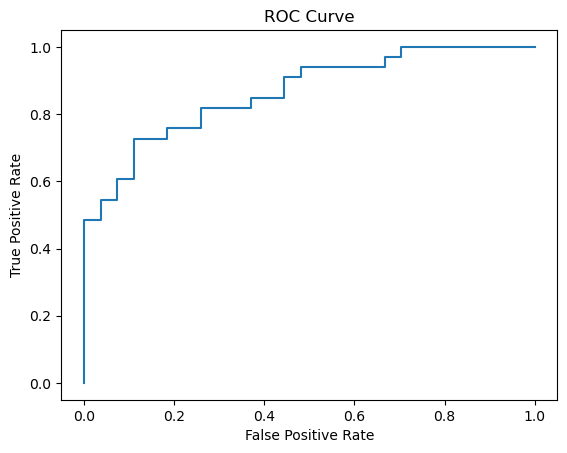

AUC: 0.8641975308641976


In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC:", auc)

In [19]:
threshold = 0.7

y_pred_new = (y_prob >= threshold).astype(int)

print("Predictions with threshold 0.7:")
print(y_pred_new[:20])

Predictions with threshold 0.7:
[0 1 0 0 0 0 1 0 0 0 0 0 1 1 1 1 0 0 0 0]


In [20]:
new_data = pd.DataFrame({
    "training_hours_week": [15],
    "age_years": [25],
    "previous_injuries": [2],
    "fatigue_score": [6],
    "position": ["Forward"],
    "league_level": ["Professional"],
    "training_type": ["Team"]
})

new_data = pd.get_dummies(new_data, drop_first=True)

new_data = new_data.reindex(columns=X.columns, fill_value=0)

new_probability = model.predict_proba(new_data)[:, 1]
new_prediction = (new_probability >= 0.7).astype(int)

print("Injury probability:", new_probability[0])
print("Prediction:", new_prediction[0])

Injury probability: 0.3420844224562649
Prediction: 0
